In [2]:
#!pip install easyocr pillow numpy opencv-python matplotlib pandas requests jiwer

In [3]:
import os
import re
import platform
import urllib.request
import requests

import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import easyocr

from PIL import Image
from jiwer import wer, cer

In [4]:
reader = easyocr.Reader(
    ['de'],
    gpu=False
)

print("EasyOCR reader loaded.")

Using CPU. Note: This module is much faster with a GPU.


EasyOCR reader loaded.


C:\ProgramData\anaconda3\envs\easyOCR_env\lib\site-packages\torch\ao\nn\quantized\dynamic\modules\rnn.py:162: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and other quantized tensor creation functions that produce tensors with dtype torch.quint8, torch.qint8, and torch.qint32 are deprecated and will be removed in a future PyTorch release. Please see https://github.com/pytorch/pytorch/issues/184982 for more information. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\quantized\Quantizer.cpp:116.)
  w_ih = torch.quantize_per_tensor(


In [5]:
import easyocr
print("EasyOCR imported successfully")

EasyOCR imported successfully


In [6]:
def draw_bounding_boxes(image_path, min_conf=0.0):
    image = cv2.imread(image_path)

    results = reader.readtext(image_path)

    img_boxes = image.copy()

    for bbox, text, conf in results:
        if text.strip() != "" and conf >= min_conf:
            pts = np.array(bbox, dtype=np.int32)

            cv2.polylines(
                img_boxes,
                [pts],
                isClosed=True,
                color=(0, 255, 0),
                thickness=1
            )

    img_boxes = cv2.cvtColor(img_boxes, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 12))
    plt.imshow(img_boxes)
    plt.title(f"Detected Text Boxes: {image_path}")
    plt.axis("off")
    plt.show()

In [7]:
ENG_IMAGES_DIR = "../images_eng"
ENG_GOLD_DIR = "../gold_english"

C:\ProgramData\anaconda3\envs\easyOCR_env\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


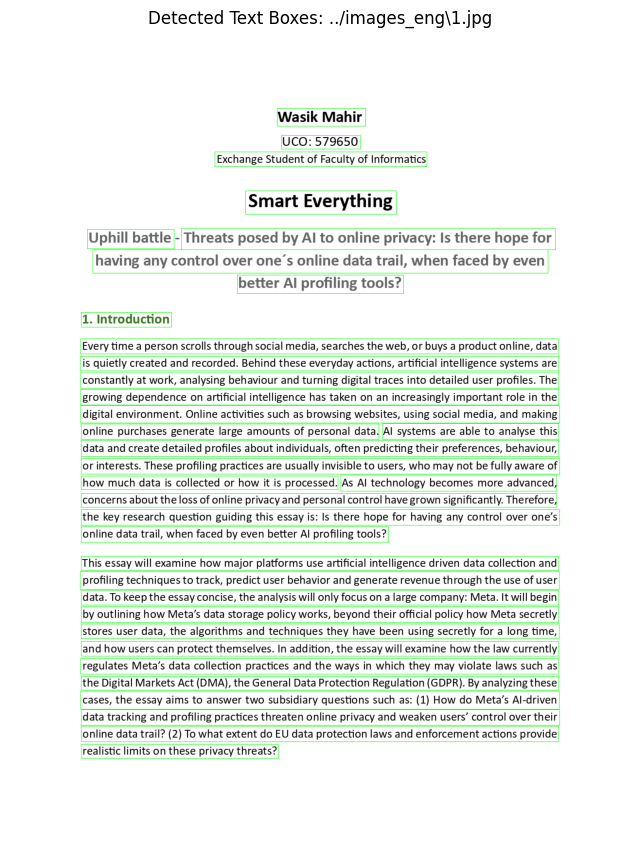

In [8]:
draw_bounding_boxes(os.path.join(ENG_IMAGES_DIR, "1.jpg"))

In [9]:
import os

output_dir = "outputs/Experiment_1"
os.makedirs(output_dir, exist_ok=True)

In [10]:
def extract_text_easyocr(image_path, min_conf=0.0):
    results = reader.readtext(
        image_path,
        paragraph=False
    )

    filtered = []

    for bbox, text, conf in results:
        if text.strip() != "" and conf >= min_conf:
            x_min = min(point[0] for point in bbox)
            y_min = min(point[1] for point in bbox)
            y_center = sum(point[1] for point in bbox) / 4

            filtered.append({
                "text": text,
                "x": x_min,
                "y": y_min,
                "y_center": y_center
            })

    filtered = sorted(filtered, key=lambda item: item["y_center"])

    lines = []
    current_line = []
    current_y = None
    line_threshold = 18

    for item in filtered:
        if current_y is None:
            current_line = [item]
            current_y = item["y_center"]

        elif abs(item["y_center"] - current_y) <= line_threshold:
            current_line.append(item)

        else:
            current_line = sorted(current_line, key=lambda item: item["x"])
            line_text = " ".join(item["text"] for item in current_line)
            lines.append(line_text)

            current_line = [item]
            current_y = item["y_center"]

    if current_line:
        current_line = sorted(current_line, key=lambda item: item["x"])
        line_text = " ".join(item["text"] for item in current_line)
        lines.append(line_text)

    return "\n".join(lines)

In [13]:
text = extract_text_easyocr(os.path.join(ENG_IMAGES_DIR, "1.jpg"),min_conf=0.0)

print(text)

C:\ProgramData\anaconda3\envs\easyOCR_env\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Wasik Mahir
UCO: 579650
Exchange Student of Faculty of Informatics
Smart Everything
Uphill battle Threats posed by Al to online privacy: Is there hope for
having any control over one' s online data trail, when faced by even
better Al profiling tools?
1. Introduction
Every time a person scrolls through social media, searches the web, or buys a product online, data
is quietly created and recorded. Behind these everyday actions, artificial intelligence systems are
constantly at work, analysing behaviour and turning digital traces into detailed user profiles. The
growing dependence on artificial intelligence has taken on an increasingly important role in the
digital environment. Online activities such as browsing websites, using social media, and making
online purchases generate large amounts of personal data. Al systems are able to analyse this
data and create detailed profiles about individuals, often predicting their preferences; behaviour;
or interests. These profiling practices are us

In [15]:
pages = [1,2,3,4,5,6] 


Page 1


C:\ProgramData\anaconda3\envs\easyOCR_env\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


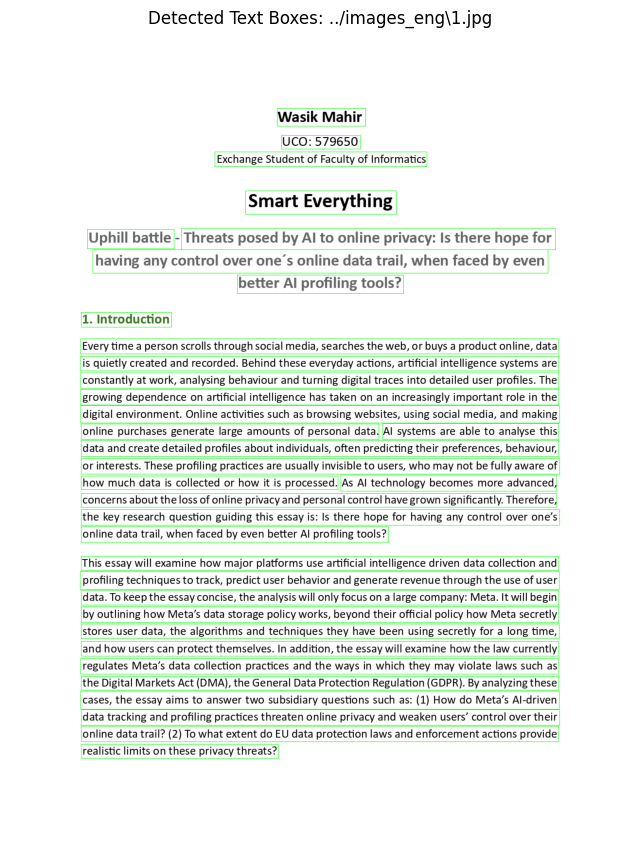

C:\ProgramData\anaconda3\envs\easyOCR_env\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Wasik Mahir
UCO: 579650
Exchange Student of Faculty of Informatics
Smart Everything
Uphill battle Threats posed by Al to online privacy: Is there hope for
having any control over one' s online data trail, when faced by even
better Al profiling tools?
1. Introduction
Every time a person scrolls through social media, searches the web, or buys a product online, data
is quietly created and recorded. Behind these everyday actions, artificial intelligence systems are
constantly at work, analysing behaviour and turning digital traces into detailed user profiles. The
growing dependence on artificial intelligence has taken on an increasingly important role in the
digital environment. Online activities such as browsing websites, using social media, and making
online purchases generate large amounts of personal data. Al systems are able to analyse this
data and create detailed profiles about individuals, often predicting their preferences; behaviour;
or interests. These profiling practices are us

C:\ProgramData\anaconda3\envs\easyOCR_env\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


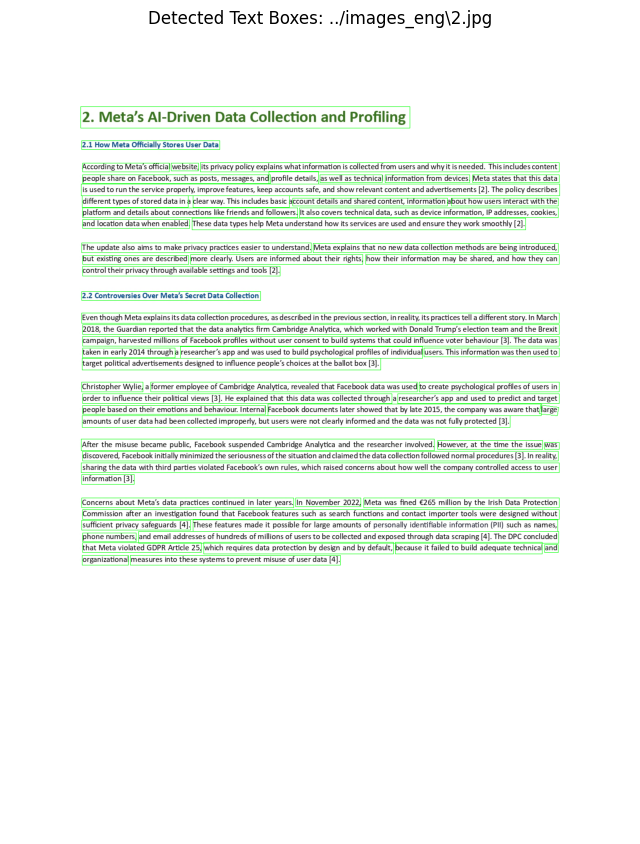

C:\ProgramData\anaconda3\envs\easyOCR_env\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


2. Meta's Al-Driven Data Collection and Profiling
2.1 How Meta Officially Stores User Data
According to Meta's officia website its privacy policy explains what information is collected from users and whyit is needed. This includes content
people share on Facebook, such as posts, messages, and profile details, as well as technica information from devices Meta states that this data
is used to run the service properly; improve features; keep accounts safe, and show relevant content and advertisements [2]. The policy describes
different types of stored data in clear way. This includes basic ccount details and shared content; information bout how users interact with the
platform and details about connections like friends and followers It also covers technical data, such as device information, IP addresses, cookies,
and location data when enabled These data types help Meta understand how its services are used and ensure they work smoothly [2]
The update also aims to make privacy practices ea

C:\ProgramData\anaconda3\envs\easyOCR_env\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


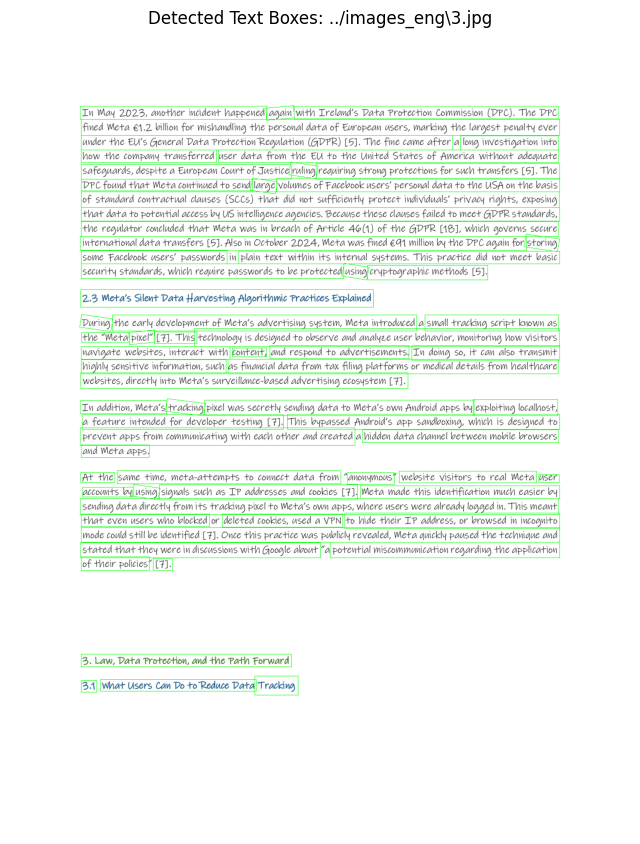

C:\ProgramData\anaconda3\envs\easyOCR_env\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In Way 2023, another incident happened again with Ireland's Data Protection Commission (DFC). The DPC
fined Meta €1.2 billion for mishandling the personal data of European users, marking the largest penalty ever
under +he EW's General Data Protection Regulation (GDPP) [5]. The fine came after long investigation into
how the company transferred user data from the EU +o the United States of America without adequate
safeguards, despite a European Court of Justice ruling requiring strong Protections for such transfers [5]. The
DPC found +hat Weta continued +0 send large Volumes of Facebook users' personal data +o the USA on +he basis
of standard contractual dauses (SCCs) +hat did no+ sufficiently Protec+ individuals' Privacy rights, exposing
that data +o Potential access by US intelligence agencies Because +hese clauses failed +o meet GDPR standards,
the regulator concluded that Meta was in breach of Article 46(1) of the GDFR [18], which governs secure
international data transfers [5]. Als

C:\ProgramData\anaconda3\envs\easyOCR_env\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


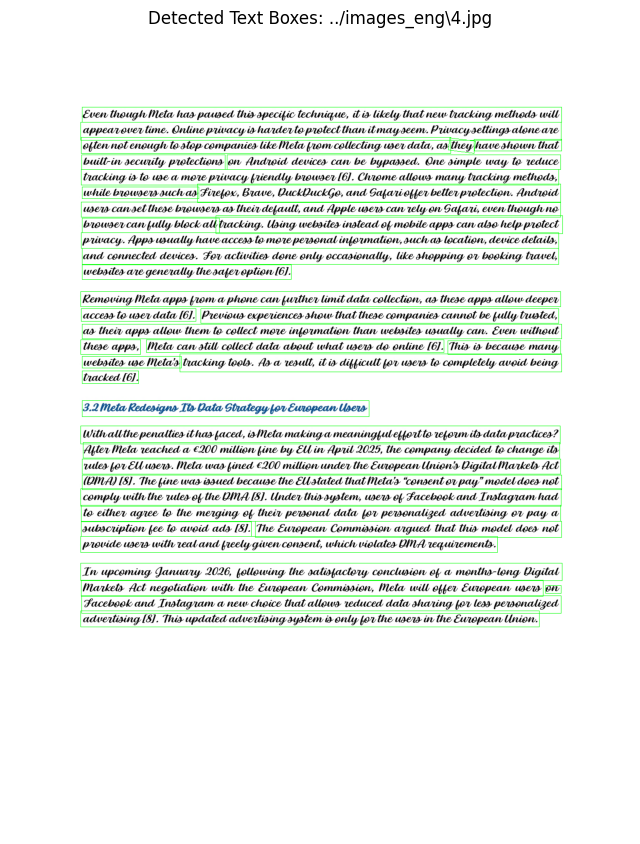

C:\ProgramData\anaconda3\envs\easyOCR_env\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Suen though Ieta haa paused this Jpecilic techique, iis likelyy that new tuacking methoda will
appeavoventime. Online pwacyi haudevto putect than itmayaeem Pwivacyaettings aloneawe
otennotenough toatop companies like Meta (uomcollecting wsevdata, a they haueahoun that
built-in aecwuty puotections on Andwoid deuices can be bypassed. Qne Jimple way to reduce
tuacking is to wsea mowe puivacyy (uendlyy bwoussev [6] . Chwome allouas many tuacking methods,
uchile bzousez auchaa Siedox; Bwave; BuckbuckGo; and Salauoevbettevpwotection. Andwid
uaeus canaettheae bwweu aa theivdefault; and Apple useus can rely on Salau, eventhoughno
bwowevcanfullyy block all 'tuacking. Using websites instead 0 mobile apps can also help pvtect
puivacyy. Appa usuallyyhaveacceaa to mowepevonal infouation;auchaa location; deuice detaila,
and connected devices. 3ov actiuities done onlyy occaaionallyy, like ahopping 0v booking tuavel,
webaites are genezally theaalevoption [6] .
Removing Meta apps (uom a phone can (with

C:\ProgramData\anaconda3\envs\easyOCR_env\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


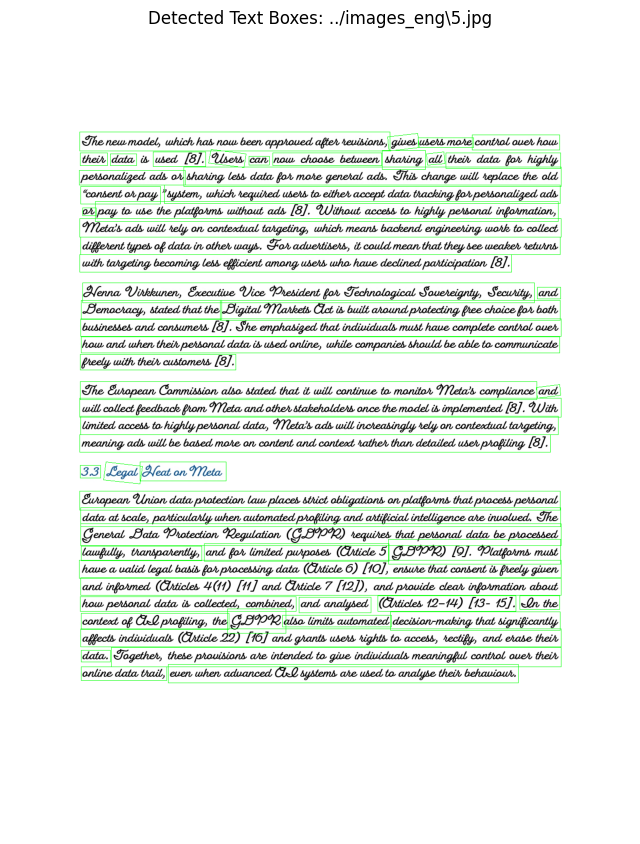

C:\ProgramData\anaconda3\envs\easyOCR_env\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Jheneumodel, which hah nou been apphoued afteh heuisionb, giues Useusmole conthol oueh hou
theih data used  [8] . QUsehs can now choole between shahing all theih data Boh highly
pehsonaliped ads @ shahing less data Pot mote genehal ads.Jhis change will heplace the old
"conbent ahpay 'system; which hequihed usehs to eitheh accept data thacking Boh pehsonaliged ads
0 pay t use the platfonmnb without ads [8] . QUithout access to highly pehbonal inpohmation;
9leta's ads will hely on contextual tauhgeting which meank backend engineehing wohk to collect
dippehent types 0} data in otheh wayh . 8ot aduehtisehs, it could mean that they bee weakeh hetuhns
with tanhgeting becoming less epßicient among usehs who haue declined pantticipation [8] .
Blenna Qinkkunen,  &xecutiue 9Uice Ipnesident Boh Jechnological Soueheignty Secwhity and
Bemochacy stated that the Bigital %)lahkets Cct is built ahound ptotecting Piee choice Pot both
businesses and consumehs [8] . She emphasiged that indiuiduals must ha

C:\ProgramData\anaconda3\envs\easyOCR_env\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


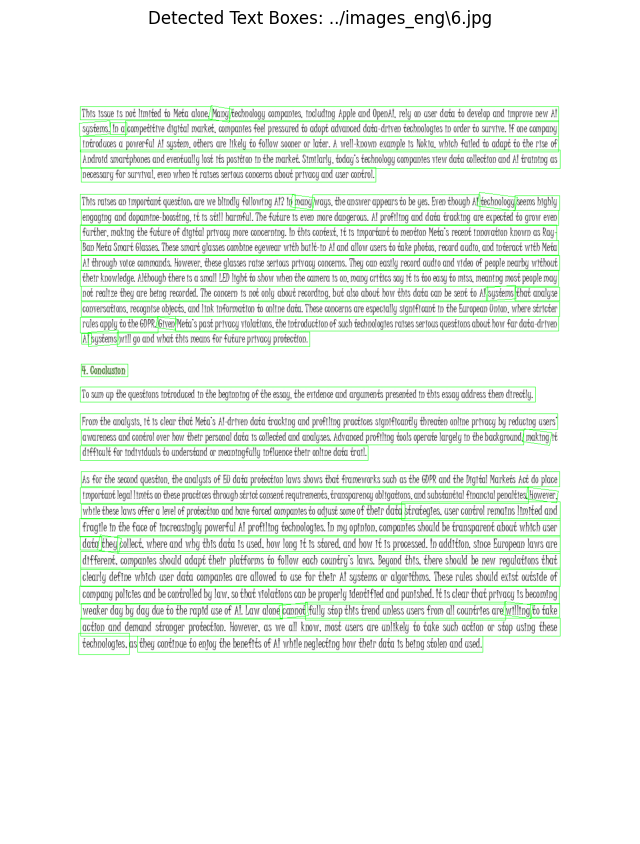

C:\ProgramData\anaconda3\envs\easyOCR_env\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


This issue is not Jimited €o Heca alone Kany technology companies, including Apple and Opena_. rely 0n user daza €o develop cnd improve new Ai
systems . In a competitive digital markec . companies feel pressured to adopt advanced data-driven technologies in order to survive. 7f one company
introduces a powerful A7 system, others are Jikely *o follow sooner or Jater . A well-knoum example is Hokia  which failed + adapt {o zhe rise of
Android smartphones and eventually Jost 16s position in the markey Similarly . {oday' s {echnology companies view data clection and 44 {raining as
necessary for survival. even when it raises serious concerns about privacy and user control.
This raises an important question: are we blindly following 44? In pany 7 ways . Ehe answer appecrs +o be ges. Even chough Ai technology  seems highly
engaging and dopamine-boosting. 7{ is still harmful. The {uture 1s eyen more dangerous. A7 profiling and data {racking are expected {o grow eyen
further . making Ehe future

In [16]:
for p in pages:
    print(f"\n==============================")
    print(f"Page {p}")
    print(f"==============================")

    image_path = os.path.join(
        ENG_IMAGES_DIR,
        f"{p}.jpg"
    )

    output_path = os.path.join(
        output_dir,
        f"page_{p}.txt"
    )

    draw_bounding_boxes(
        image_path,
        min_conf=0.0
    )
    
    output_text = extract_text_easyocr(
        image_path,
        min_conf=0.0
    )

    print(output_text)

    with open(output_path, "w", encoding="utf-8") as f:
        f.write(output_text)

    print(f"Saved: {output_path}")

In [25]:
def normalize_text(text):
    text = text.lower()
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    return text

In [26]:
results_exp1 = []

for p in pages:
    print(f"Evaluating page {p}...")

    gold_path = os.path.join(ENG_GOLD_DIR, f"{p}.txt")

    with open(gold_path, "r", encoding="utf-8") as f:
        gold_text = f.read()

    pred_path = os.path.join(output_dir, f"page_{p}.txt")

    with open(pred_path, "r", encoding="utf-8") as f:
        pred_text = f.read()

    gold_norm = normalize_text(gold_text)
    pred_norm = normalize_text(pred_text)

    wer_score = wer(gold_norm, pred_norm)
    cer_score = cer(gold_norm, pred_norm)

    results_exp1.append({
        "page": p,
        "WER": wer_score,
        "CER": cer_score
    })

Evaluating page 1...
Evaluating page 2...
Evaluating page 3...
Evaluating page 4...
Evaluating page 5...
Evaluating page 6...


In [27]:
print("=== Experiment 1 Results: EasyOCR ===")
df_exp1 = pd.DataFrame(results_exp1)
df_exp1

=== Experiment 1 Results: EasyOCR ===


,page,WER,CER
0,1,0.043038,0.007134
1,2,0.083761,0.013863
2,3,0.191721,0.035270
3,4,0.632184,0.160150
4,5,0.579082,0.138737
5,6,0.348485,0.064430


In [28]:
mean_wer = df_exp1["WER"].mean()
mean_cer = df_exp1["CER"].mean()

print("=== Experiment 1 Results ===")
print(f"Mean WER: {mean_wer:.4f}")
print(f"Mean CER: {mean_cer:.4f}")

=== Experiment 1 Results ===
Mean WER: 0.3130
Mean CER: 0.0699


In [29]:
import os

output_dir_result_1 = "outputs/Results"
os.makedirs(output_dir_result_1, exist_ok=True)

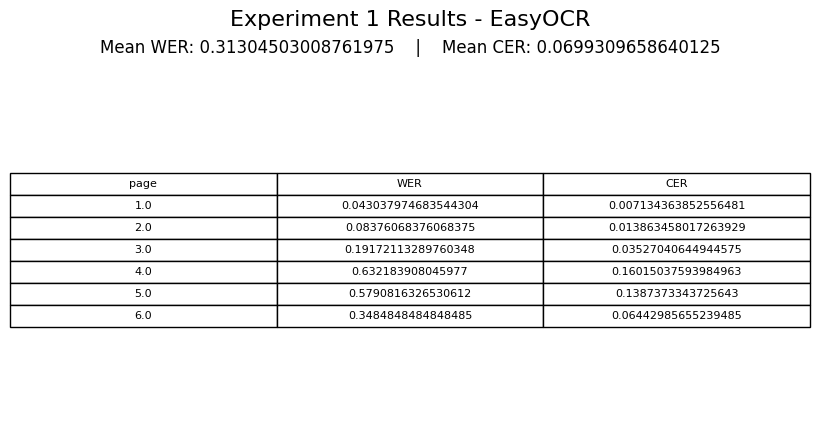

Saved: outputs/Results\experiment_1_english_easyocr_results.png


In [31]:
import os
import matplotlib.pyplot as plt

mean_wer = df_exp1["WER"].mean()
mean_cer = df_exp1["CER"].mean()

save_path = os.path.join(output_dir_result_1, "experiment_1_english_easyocr_results.png")

fig, ax = plt.subplots(figsize=(10, len(df_exp1) * 0.45 + 2))
ax.axis("off")


fig.suptitle("Experiment 1 Results - EasyOCR", fontsize=16, y=0.98)

summary_text = f"Mean WER: {mean_wer}    |    Mean CER: {mean_cer}"
fig.text(0.5, 0.90, summary_text, ha="center", va="center", fontsize=12)

# Table
table = ax.table(
    cellText=df_exp1.values,
    colLabels=df_exp1.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.3)

ax.set_position([0.1, 0.08, 0.8, 0.78])

fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)

print("Saved:", save_path)

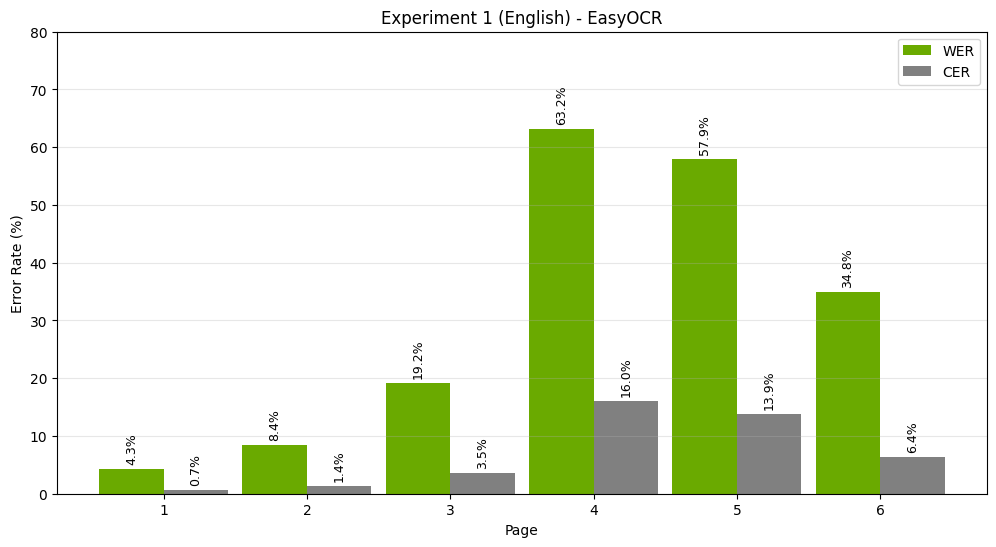

In [32]:
# with vector graphics
import numpy as np
x = np.arange(len(df_exp1))
width = 0.45

wer_pct = df_exp1["WER"] * 100
cer_pct = df_exp1["CER"] * 100

plt.figure(figsize=(12,6))

bars1 = plt.bar(x - width/2,wer_pct,width,label="WER",color="#6AAA00")
bars2 = plt.bar(x + width/2,cer_pct,width,label="CER",color="#808080")

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,      
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9,
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

plt.xticks(x, df_exp1["page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 1 (English) - EasyOCR")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.ylim(0, 80)
plt.yticks(np.arange(0, 81, 10))

os.makedirs(output_dir_result_1, exist_ok=True)

plt.savefig(os.path.join(output_dir_result_1,"experiment_1_english_easyocr_wer_cer_by_page.pdf"),bbox_inches="tight")

plt.show()